# Inspect Pipe Outputs



This notebook is for visually inspecting the pipe diagnosis outputs under demo_outputs/pipe_stage_diagnosis/pipe.



It does three things:

1. Loads the quantitative metrics from results.json.

2. Shows the first-layer panorama used in the spherical representation.

3. Renders the generated ply meshes as static matplotlib subplots so you can compare failure modes and fixes side by side.


In [7]:
from pathlib import Path

import json



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import trimesh

import open3d as o3d

from matplotlib import colors as mcolors

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from PIL import Image

from IPython.display import display



ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:

    if (candidate / 'demo_outputs').exists():

        ROOT = candidate

        break

RESULT_JSON = ROOT / 'demo_outputs' / 'pipe_stage_diagnosis' / 'results.json'

PIPE_DIR = ROOT / 'demo_outputs' / 'pipe_stage_diagnosis' / 'pipe'

assert RESULT_JSON.exists(), RESULT_JSON

assert PIPE_DIR.exists(), PIPE_DIR


In [8]:
with open(RESULT_JSON, 'r', encoding='utf-8') as handle:
    results = json.load(handle)

pipe = results['samples']['pipe']
rows = []
for name, stats in pipe['methods'].items():
    rows.append({
        'method': name,
        'faces': stats['faces'],
        'components': stats['components'],
        'chamfer_mean': stats['chamfer_mean'],
        'chamfer_p90': stats['chamfer_p90'],
        'fscore_2pct': stats['fscore_2pct'],
        'out_path': stats['out_path'],
    })

df = pd.DataFrame(rows).sort_values('chamfer_mean').reset_index(drop=True)
display(df)
print('raw bbox diag      :', pipe['bbox_diag'])
print('reference bbox diag:', pipe['reference_bbox_diag'])
print('raw point count     :', pipe['point_clouds']['raw']['count'])
print('voxel point count   :', pipe['point_clouds']['voxel']['count'])

,method,faces,components,chamfer_mean,chamfer_p90,fscore_2pct,out_path
0,exact_ray_bpa,1530,10,0.026088,0.079215,0.904920,demo_outputs/pipe_stage_diagnosis/pipe/exact_r...
1,exact_ray_poisson,5816,7,0.039860,0.118258,0.799943,demo_outputs/pipe_stage_diagnosis/pipe/exact_r...
2,subdivided_inversion_poisson,7260,8,0.069022,0.172009,0.622876,demo_outputs/pipe_stage_diagnosis/pipe/subdivi...
3,subdivided_inversion_bpa,2281,16,0.111281,0.366548,0.595500,demo_outputs/pipe_stage_diagnosis/pipe/subdivi...
4,angle_area_poisson,115241,432,2.056315,3.103957,0.005547,demo_outputs/pipe_stage_diagnosis/pipe/angle_a...
5,vggt_like_poisson,243600,304,2.251401,3.605962,0.005050,demo_outputs/pipe_stage_diagnosis/pipe/vggt_li...
6,voxel_poisson,254653,241,2.798249,4.664395,0.003669,demo_outputs/pipe_stage_diagnosis/pipe/voxel_p...
7,voxel_bpa,96316,34,2.956819,4.859396,0.001289,demo_outputs/pipe_stage_diagnosis/pipe/voxel_b...
8,layered_pano_mesh,211991,2075,3.026266,4.570918,0.003466,demo_outputs/pipe_stage_diagnosis/pipe/layered...


raw bbox diag      : 22.304298400878906
reference bbox diag: 3.318865498586869
raw point count     : 71024
voxel point count   : 53937


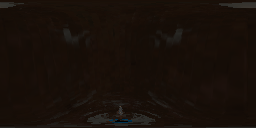

In [3]:
pano_path = PIPE_DIR / 'layer0_pano.png'
display(Image.open(pano_path))

In [11]:
def load_mesh_for_display(path, target_faces=12000):

    mesh = trimesh.load(path, process=False)

    if isinstance(mesh, trimesh.Scene):

        meshes = [geom for geom in mesh.geometry.values() if isinstance(geom, trimesh.Trimesh)]

        if len(meshes) != 1:

            raise ValueError(f'Expected one mesh in scene, got {len(meshes)}')

        mesh = meshes[0]



    if len(mesh.faces) > target_faces:

        o3d_mesh = o3d.geometry.TriangleMesh()

        o3d_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices))

        o3d_mesh.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.faces))

        if hasattr(mesh.visual, 'vertex_colors') and mesh.visual.vertex_colors is not None and len(mesh.visual.vertex_colors) == len(mesh.vertices):

            o3d_mesh.vertex_colors = o3d.utility.Vector3dVector(np.asarray(mesh.visual.vertex_colors)[:, :3] / 255.0)

        o3d_mesh = o3d_mesh.simplify_quadric_decimation(target_number_of_triangles=target_faces)

        mesh = trimesh.Trimesh(

            vertices=np.asarray(o3d_mesh.vertices),

            faces=np.asarray(o3d_mesh.triangles),

            process=False,

        )



    return mesh





def normalized_mesh(mesh):

    verts = np.asarray(mesh.vertices).astype(np.float32)

    faces = np.asarray(mesh.faces)

    center = 0.5 * (verts.min(axis=0) + verts.max(axis=0))

    scale = np.max(verts.max(axis=0) - verts.min(axis=0))

    scale = max(float(scale), 1e-6)

    verts = (verts - center) / scale

    return verts, faces





def face_colors_for_mesh(mesh, base_color='#7aa6ff'):

    faces = np.asarray(mesh.faces)

    rgba = np.ones((len(faces), 4), dtype=np.float32)

    rgba[:, :3] = np.array(mcolors.to_rgb(base_color), dtype=np.float32)



    if hasattr(mesh.visual, 'vertex_colors') and mesh.visual.vertex_colors is not None and len(mesh.visual.vertex_colors) == len(mesh.vertices):

        vertex_colors = np.asarray(mesh.visual.vertex_colors)[:, :3].astype(np.float32) / 255.0

        rgba[:, :3] = vertex_colors[faces].mean(axis=1)



    return rgba





def plot_mesh_matplotlib(ax, mesh, title, base_color='#7aa6ff'):

    verts, faces = normalized_mesh(mesh)

    triangles = verts[faces]

    face_rgba = face_colors_for_mesh(mesh, base_color=base_color)

    normals = np.cross(triangles[:, 1] - triangles[:, 0], triangles[:, 2] - triangles[:, 0])

    normal_norm = np.linalg.norm(normals, axis=1, keepdims=True)

    normals = normals / np.clip(normal_norm, 1e-8, None)

    light_dir = np.array([0.35, -0.45, 0.82], dtype=np.float32)

    light_dir /= np.linalg.norm(light_dir)

    intensity = np.clip(0.30 + 0.70 * np.abs(normals @ light_dir), 0.0, 1.0)

    face_rgba[:, :3] = np.clip(face_rgba[:, :3] * intensity[:, None], 0.0, 1.0)



    collection = Poly3DCollection(

        triangles,

        facecolors=face_rgba,

        linewidths=0.05,

        edgecolors=(0, 0, 0, 0.03),

        alpha=1.0,

    )

    ax.add_collection3d(collection)

    ax.set_xlim(-0.55, 0.55)

    ax.set_ylim(-0.55, 0.55)

    ax.set_zlim(-0.55, 0.55)

    ax.set_box_aspect((1, 1, 1))

    ax.view_init(elev=18, azim=35)

    ax.set_axis_off()

    ax.set_facecolor('white')

    ax.set_title(title, fontsize=10, pad=8)


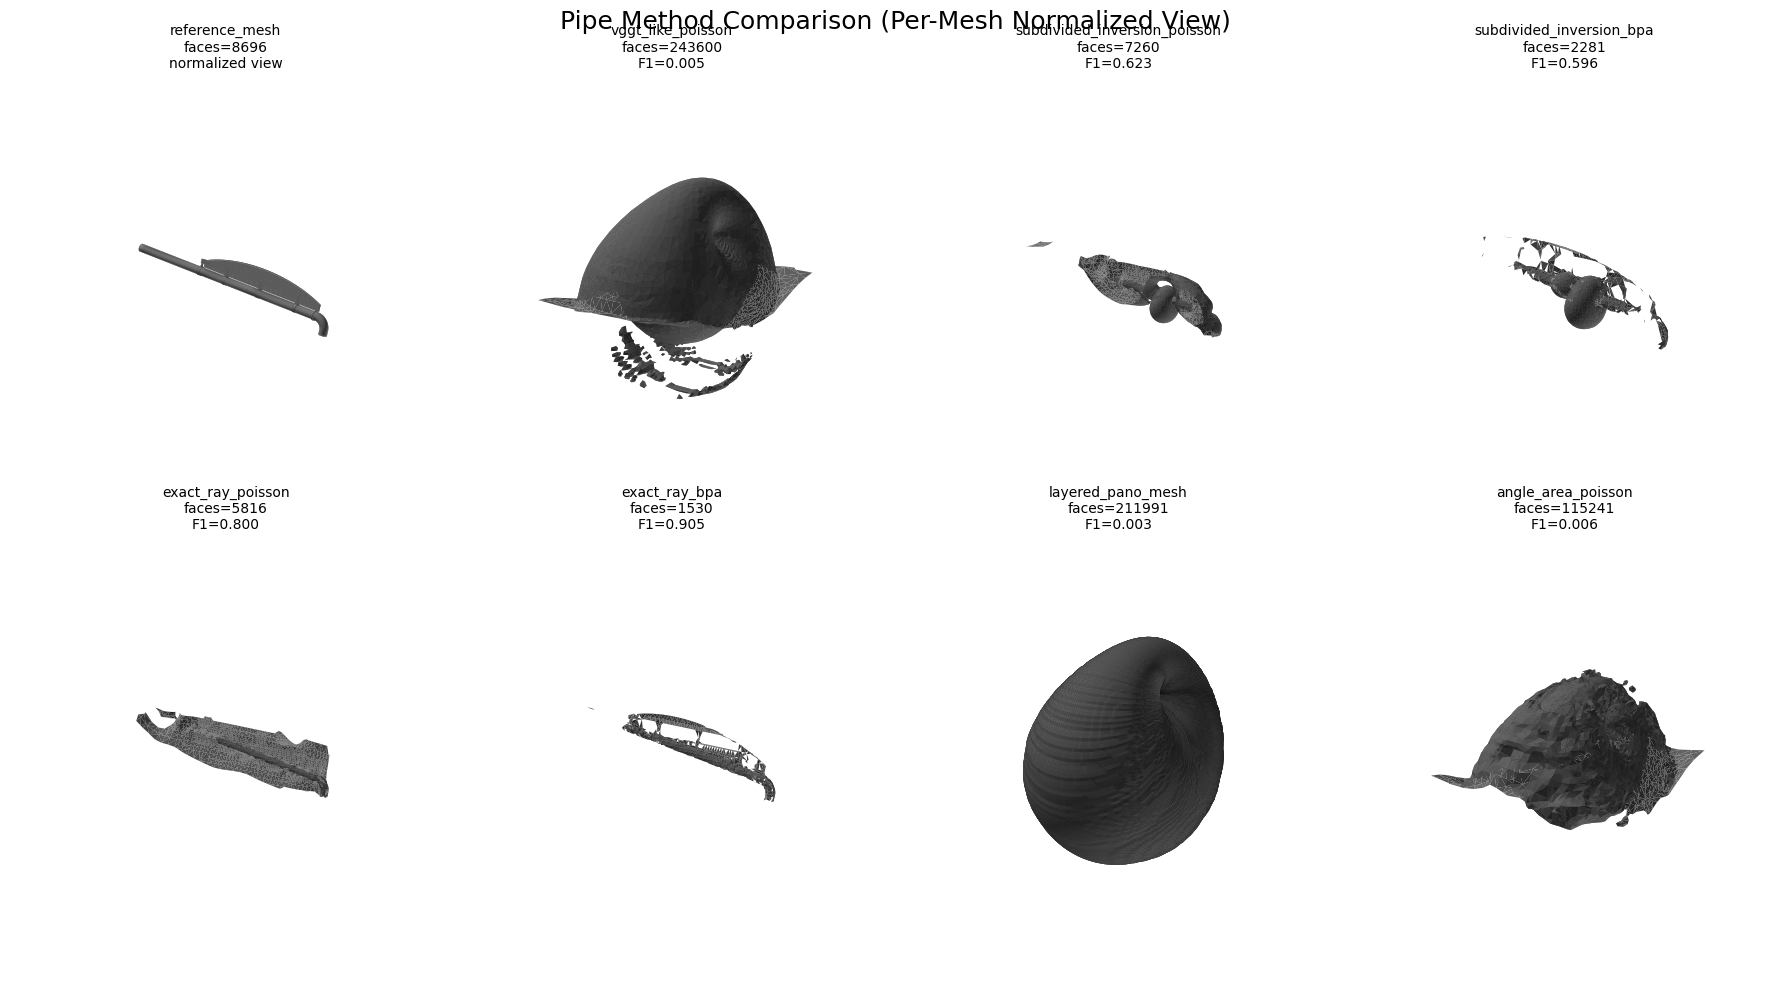

In [12]:
compare_items = [

    ('reference_mesh', ROOT / pipe['mesh_path'], '#8f8f8f'),

    ('vggt_like_poisson', ROOT / pipe['methods']['vggt_like_poisson']['out_path'], '#809bce'),

    ('subdivided_inversion_poisson', ROOT / pipe['methods']['subdivided_inversion_poisson']['out_path'], '#7dbf9a'),

    ('subdivided_inversion_bpa', ROOT / pipe['methods']['subdivided_inversion_bpa']['out_path'], '#a2c97f'),

    ('exact_ray_poisson', ROOT / pipe['methods']['exact_ray_poisson']['out_path'], '#f2a65a'),

    ('exact_ray_bpa', ROOT / pipe['methods']['exact_ray_bpa']['out_path'], '#e76f51'),

    ('layered_pano_mesh', ROOT / pipe['methods']['layered_pano_mesh']['out_path'], '#d16ba5'),

    ('angle_area_poisson', ROOT / pipe['methods']['angle_area_poisson']['out_path'], '#6fa8dc'),

]



meshes = []

for label, path, color in compare_items:

    meshes.append((label, load_mesh_for_display(path, target_faces=12000), color))



fig = plt.figure(figsize=(18, 10), facecolor='white')

axes = [fig.add_subplot(2, 4, index + 1, projection='3d') for index in range(len(meshes))]



for ax, (label, mesh, color) in zip(axes, meshes):

    if label == 'reference_mesh':

        title = f'reference_mesh\nfaces={len(mesh.faces)}\nnormalized view'

    else:

        stats = pipe['methods'][label]

        title = f"{label}\nfaces={stats['faces']}\nF1={stats['fscore_2pct']:.3f}"

    plot_mesh_matplotlib(ax, mesh, title=title, base_color=color)



fig.suptitle('Pipe Method Comparison (Per-Mesh Normalized View)', fontsize=18, y=0.98)

plt.tight_layout()

plt.show()


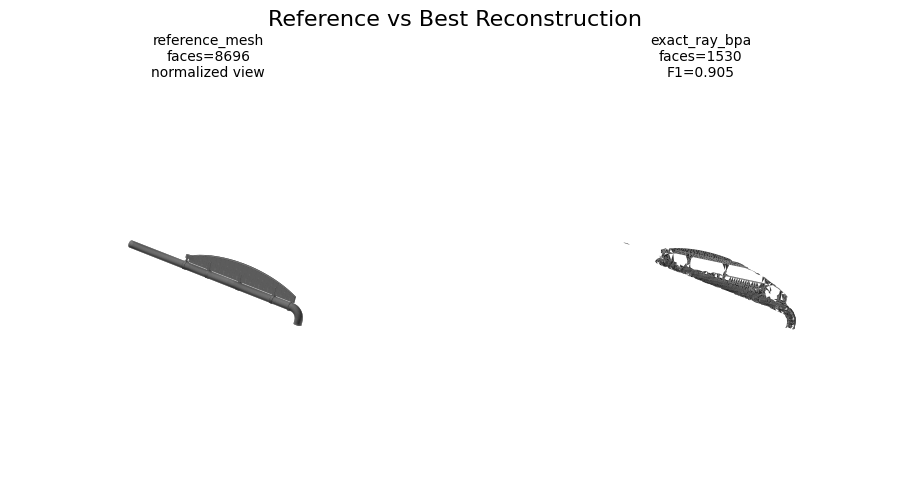

In [13]:
detail_items = [

    ('reference_mesh', ROOT / pipe['mesh_path'], '#8f8f8f'),

    ('exact_ray_bpa', ROOT / pipe['methods']['exact_ray_bpa']['out_path'], '#e76f51'),

]



detail_meshes = []

for label, path, color in detail_items:

    detail_meshes.append((label, load_mesh_for_display(path, target_faces=20000), color))



fig = plt.figure(figsize=(10, 5), facecolor='white')

axes = [fig.add_subplot(1, 2, index + 1, projection='3d') for index in range(2)]



for ax, (label, mesh, color) in zip(axes, detail_meshes):

    if label == 'reference_mesh':

        title = f'reference_mesh\nfaces={len(mesh.faces)}\nnormalized view'

    else:

        stats = pipe['methods'][label]

        title = f"{label}\nfaces={stats['faces']}\nF1={stats['fscore_2pct']:.3f}"

    plot_mesh_matplotlib(ax, mesh, title=title, base_color=color)



fig.suptitle('Reference vs Best Reconstruction', fontsize=16, y=0.98)

plt.tight_layout()

plt.show()


## How to Read This Notebook

- `vggt_like_poisson` is the dense point-cloud meshing baseline.
- `subdivided_inversion_*` keeps the inversion idea but refines the mesh before inversion.
- `exact_ray_*` computes the layered spherical representation directly from inward ray intersections on the original mesh.
- `layered_pano_mesh` is the direct panorama-topology mesh, which is useful diagnostically but not a good final surface.